## Data Cleaning Automation Assignment

### Question 10 (prior questions 1-9 were conceptual and only in MyEducator)

**Goal**: Create a function named wrangle_basic(df) that cleans categorical text fields to eliminate data quality issues caused by inconsistent data entry.

Your function requirements:

* Identify which categorical columns have data quality issues
* Create cleaned versions of problematic columns (append "_clean" to column names; do not overwrite originals)
* Ensure that semantically identical values are represented consistently
* Preserve the original number of rows
* Use logic that would generalize to new data with similar patterns

**Hint**: Start by exploring the unique values in categorical columns to identify patterns of inconsistency.

Check question: After running your function, how many rows are labeled as "failed" in delivery_status_clean?

In [4]:
# Question 10
import pandas as pd
import numpy as np
import re
from pathlib import Path

# Load data once for the assignment

DATA_PATH_CANDIDATES = [
    Path("last_mile_delivery_stops_1000.csv"),
    Path("Chapter-7/last_mile_delivery_stops_1000.csv"),
]
for _p in DATA_PATH_CANDIDATES:
    if _p.exists():
        data_path = _p
        break
else:
    raise FileNotFoundError(
        "Could not find last_mile_delivery_stops_1000.csv. "
        "Run this notebook from the repo root or from the Chapter-7 folder."
    )

df_raw = pd.read_csv(data_path)


def _normalize_basic(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip().lower()
    text = re.sub(r"\s+", " ", text)
    return text


def _normalize_key(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip().lower()
    text = re.sub(r"[\s_]+", "-", text)
    text = re.sub(r"[^a-z0-9-]+", "", text)
    text = re.sub(r"-{2,}", "-", text)
    return text


def wrangle_basic(df):
    # Clean key categorical fields and create *_clean columns.
    df = df.copy()

    if "hub" in df.columns:
        hub_norm = df["hub"].apply(_normalize_key)
        hub_map = {
            "boulder": "boulder",
            "fort-collins": "fort-collins",
            "fortcollins": "fort-collins",
            "colorado-springs": "colorado-springs",
            "coloradosprings": "colorado-springs",
            "denver-east": "denver-east",
            "dnvr-east": "denver-east",
            "denver-west": "denver-west",
        }
        df["hub_clean"] = hub_norm.map(hub_map).fillna(hub_norm)

    if "delivery_zone" in df.columns:
        df["delivery_zone_clean"] = df["delivery_zone"].apply(_normalize_basic)

    if "customer_type" in df.columns:
        cust_norm = df["customer_type"].apply(_normalize_basic)
        cust_map = {
            "biz": "business",
            "business": "business",
            "res": "residential",
            "residential": "residential",
        }
        df["customer_type_clean"] = cust_norm.map(cust_map).fillna(cust_norm)

    if "priority_level" in df.columns:
        pr_norm = df["priority_level"].apply(_normalize_basic)
        pr_norm = pr_norm.str.replace(r"[\s-]+", "_", regex=True)
        pr_map = {
            "expedite": "expedited",
            "expedited": "expedited",
            "same_day": "same_day",
            "same day": "same_day",
            "standard": "standard",
        }
        df["priority_level_clean"] = pr_norm.map(pr_map).fillna(pr_norm)

    if "delivery_status" in df.columns:
        status_norm = df["delivery_status"].apply(_normalize_basic)
        status_norm = status_norm.str.replace(r"[\s-]+", "_", regex=True)
        status_map = {
            "delivered": "delivered",
            "failed": "failed",
            "faild": "failed",
            "rescheduled": "rescheduled",
            "resheduled": "rescheduled",
        }
        df["delivery_status_clean"] = status_norm.map(status_map).fillna(status_norm)

    return df


df_q10 = wrangle_basic(df_raw)
df_q10.head()

# How many rows are labelled as 'failed' in the 'delivery_status_clean' column?
failed_count = df_q10[df_q10["delivery_status_clean"] == "failed"].shape[0]
print(failed_count)


280


### Question 11

**Goal**: Create a function named add_datetime_features(df) that converts messy datetime strings into usable datetime objects and creates time-based analytical features.

Your function requirements:

* Parse datetime information from text columns that contain date/time data
  * Handle inconsistent formatting (different date orders, 12/24-hour time, timezone tokens)
  * Successfully parse at least these columns: stop_datetime_raw, scheduled_window_start_raw
  * Create parsed versions with appropriate naming to distinguish from originals

* Engineer time-based features for analysis:
  * Day of week indicator (numeric, starting with Monday)
  * Weekend indicator (binary: weekend vs weekday)
  * Delivery lateness metric that compares actual arrival time to the scheduled window

**Hint**: The actual_arrival_min column contains minutes from midnight. Your lateness metric should be comparable to this scale and never negative.

**Check question**: After running your function (on the output of Question 10), what is the mean of your lateness metric, rounded to 2 decimals?

In [5]:
# Question 11

def _parse_messy_datetime(series):
    if series is None:
        return series
    s = series.copy()
    s = s.astype("string")
    s = s.str.replace(r"\b[A-Z]{2,4}\b", "", regex=True)
    s = s.str.replace(r"\s+", " ", regex=True).str.strip()
    return pd.to_datetime(s, errors="coerce", format="mixed")


def add_datetime_features(df):
    # Parse messy datetime strings and engineer time-based features.
    df = df.copy()

    if "stop_datetime_raw" in df.columns:
        df["stop_datetime"] = _parse_messy_datetime(df["stop_datetime_raw"])

    if "scheduled_window_start_raw" in df.columns:
        df["scheduled_window_start"] = _parse_messy_datetime(df["scheduled_window_start_raw"])

    if "stop_datetime" in df.columns:
        df["stop_dayofweek"] = df["stop_datetime"].dt.dayofweek
        df["stop_is_weekend"] = (df["stop_dayofweek"] >= 5).astype("int64")

    if "actual_arrival_min" in df.columns and "scheduled_window_min" in df.columns:
        actual = pd.to_numeric(df["actual_arrival_min"], errors="coerce")
        scheduled = pd.to_numeric(df["scheduled_window_min"], errors="coerce")
        df["lateness_min"] = (actual - scheduled).clip(lower=0)

    return df


df_q11 = add_datetime_features(df_q10)
df_q11[["stop_datetime", "scheduled_window_start", "stop_dayofweek", "stop_is_weekend", "lateness_min"]].head()

# what is the mean of the 'lateness_min' column rounded to two decimal places?
mean_lateness = round(df_q11["lateness_min"].mean(), 2)
print(mean_lateness)


297.3


### Question 12

**Goal**: Create a function named bin_rare_categories(df, cols=None, min_prop=0.05, suffix='_binned') that consolidates infrequent categories to reduce cardinality.

Your function requirements:

* Accept flexible column specification:
  * If `cols=None` (default), process all categorical columns in the DataFrame
  * If `cols` is a string, process that single column
  * If `cols` is a list, process those specific columns
  
* Reduce category cardinality by grouping rare values:
  * Calculate the frequency of each category as a proportion of total rows
  * Categories that appear too infrequently should be consolidated into a single group
  * The threshold for "infrequent" is controlled by the `min_prop` parameter (default: 0.05)
  
* Create new binned columns:
  * Add a suffix to distinguish binned columns from originals (controlled by `suffix` parameter, default: '_binned')
  * Preserve all rows (no filtering)

**Hint**: Common practice is to label consolidated rare categories as "Other"

**Check question**: After running your function on delivery_zone_clean (from Question 11 output) with default parameters, how many unique categories exist in the resulting binned column?

In [6]:
# Question 12

def bin_rare_categories(df, cols=None, min_prop=0.05, suffix="_binned"):
    # Bin infrequent categorical values into 'Other'.
    df = df.copy()

    if cols is None:
        cols = df.select_dtypes(include=["object", "category", "string"]).columns.tolist()
    elif isinstance(cols, str):
        cols = [cols]
    else:
        cols = list(cols)

    for col in cols:
        if col not in df.columns:
            continue
        s = df[col]
        freq = s.value_counts(normalize=True, dropna=True)
        rare_vals = freq[freq < min_prop].index
        df[f"{col}{suffix}"] = s.where(~s.isin(rare_vals), other="Other")

    return df


df_q12 = bin_rare_categories(df_q11)
df_q12.filter(like="delivery_zone_clean").head()

# how many unique values are in the 'delivery_zone_clean_binned' column?
unique_values_count = df_q12["delivery_zone_clean_binned"].nunique()
print(unique_values_count)


5


### Question 13

**Goal**: Create a function named transform_skew(df, features=None, suffix='_skewfix') that reduces skew in numeric columns by automatically selecting the best transformation.

Your function requirements:

* Accept flexible feature specification:
  * If `features=None` (default), process all numeric non-boolean columns
  * If `features` is a string, process that single column
  * If `features` is a list, process those specific columns

* Handle data with varied characteristics:
  * Some columns may contain negative values, zeros, or missing values
  * Your transformations must handle these gracefully without errors
  * Consider using a shift strategy for transforms that require non-negative inputs

* Evaluate multiple transformation strategies:
  * Test several monotonic transformations including no transformation as a baseline
  * Include both traditional power transformations AND advanced statistical transformations
  * Research the Yeo-Johnson transformation - a powerful method that handles negative values natively
  * Select the transformation that minimizes the absolute value of skewness
  * Implement a consistent tie-breaking strategy if multiple transformations produce similar results

* Create new columns with appropriate naming:
  * Use the `suffix` parameter to distinguish transformed columns from originals (default: '_skewfix')
  * Preserve all rows and original columns

**Hints**: 
- Skewness can be calculated with `.skew(skipna=True)`
- For transforms requiring non-negative inputs: consider shifting data so minimum becomes zero
- The Yeo-Johnson transformation is available in scipy.stats and works with negative values
- Common power transformations: logarithmic (log1p), square root, cube root
- When comparing transformations, focus on which produces skewness closest to zero

**Check question**: After running your function on distance_from_prev_mi (from Question 12 output) with default parameters, what is the skewness of the transformed column, rounded to 3 decimals?

In [7]:
# Question 13

def _yeo_johnson_transform(values, lmbda):
    values = values.astype("float64", copy=False)
    out = np.full_like(values, np.nan, dtype="float64")
    mask = np.isfinite(values)
    if not mask.any():
        return out

    y = values[mask]
    pos = y >= 0
    out_vals = np.empty_like(y, dtype="float64")

    if abs(lmbda) > 1e-8:
        out_vals[pos] = ((y[pos] + 1) ** lmbda - 1) / lmbda
    else:
        out_vals[pos] = np.log1p(y[pos])

    if abs(lmbda - 2) > 1e-8:
        out_vals[~pos] = -(((-y[~pos] + 1) ** (2 - lmbda) - 1) / (2 - lmbda))
    else:
        out_vals[~pos] = -np.log1p(-y[~pos])

    out[mask] = out_vals
    return out


def transform_skew(df, features=None, suffix="_skewfix"):
    # Reduce skew by selecting the best transformation per feature.
    df = df.copy()

    if features is None:
        features = [
            c for c in df.select_dtypes(include=[np.number]).columns
            if df[c].dtype != "bool"
        ]
    elif isinstance(features, str):
        features = [features]
    else:
        features = list(features)

    def _shift_for_nonneg(series):
        min_val = series.min(skipna=True)
        if pd.isna(min_val) or min_val >= 0:
            return 0.0
        return -min_val

    for col in features:
        if col not in df.columns:
            continue

        s = df[col].astype("float64")
        shift = _shift_for_nonneg(s)

        candidates = []
        candidates.append(("none", s))

        try:
            candidates.append(("log1p", np.log1p(s + shift)))
        except Exception:
            pass

        try:
            candidates.append(("sqrt", np.sqrt(s + shift)))
        except Exception:
            pass

        candidates.append(("cbrt", np.cbrt(s)))

        # Yeo-Johnson with a lambda grid search
        lambdas = np.linspace(-2.0, 2.0, 41)
        best_yj = None
        best_yj_score = None
        for lmbda in lambdas:
            transformed = pd.Series(
                _yeo_johnson_transform(s.to_numpy(), lmbda),
                index=s.index,
                name=s.name,
            )
            score = abs(transformed.skew(skipna=True))
            if best_yj_score is None or score < best_yj_score:
                best_yj_score = score
                best_yj = transformed
        if best_yj is not None:
            candidates.append(("yeo_johnson", best_yj))

        best_series = None
        best_score = None
        tol = 1e-6

        for name, series in candidates:
            score = abs(series.skew(skipna=True))
            if pd.isna(score):
                continue
            if best_score is None or score < best_score - tol:
                best_score = score
                best_series = series

        df[f"{col}{suffix}"] = best_series if best_series is not None else s

    return df


df_q13 = transform_skew(df_q12)
df_q13.filter(like="distance_from_prev_mi").head()

# What is the skewness of the transformed column, rounded to 3 decimal places?
skewness = round(df_q13["distance_from_prev_mi_skewfix"].skew(skipna=True), 3)
print(skewness)


-0.233


### Question 14

**Goal**: Create a function named impute_missing(df, features=None, group_cols=None) that fills in missing values without losing any data rows.

Your function requirements:

* Accept flexible feature specification:
  * If `features=None` (default), impute all columns that contain missing values
  * If `features` is a string, impute that single column
  * If `features` is a list, impute only those specific columns

* Accept flexible grouping specification:
  * If `group_cols=None` (default), automatically select logical grouping columns from the data
  * Look for cleaned categorical columns that represent natural groups (e.g., location, category indicators)
  * If `group_cols` is a list, use those specific columns for grouping

* Implement intelligent imputation strategies:
  * Use different strategies for numeric vs categorical data
  * Apply group-based imputation first (calculate statistics within groups)
  * Fall back to global imputation when group-based values are unavailable
  * Ensure deterministic results (same input always produces same output)

* Preserve all rows:
  * Never drop rows or columns
  * All missing values must be filled

**Hints**:
- For numeric data: central tendency measures like median work well
- For categorical data: most frequent values (mode) are appropriate
- Group-based imputation: calculate statistics separately for each group, then use those to fill within-group missing values
- Fallback strategy: if a group has all missing values, use the overall (global) statistic

**Check question**: After running your function on the output of Question 13, what is the mean of cargo_temp_f for records where hub_clean == "denver-east", rounded to 2 decimal places?

In [8]:
# Question 14

def impute_missing(df, features=None, group_cols=None):
    # Impute missing values using group-based statistics with global fallback.
    df = df.copy()

    if features is None:
        features = [c for c in df.columns if df[c].isna().any()]
    elif isinstance(features, str):
        features = [features]
    else:
        features = list(features)

    if group_cols is None:
        group_cols = [
            c for c in df.columns
            if c.endswith("_clean") and df[c].dtype == "object"
        ]
    elif isinstance(group_cols, str):
        group_cols = [group_cols]
    else:
        group_cols = list(group_cols)

    group_cols = [c for c in group_cols if c in df.columns]

    for col in features:
        if col not in df.columns:
            continue

        is_numeric = pd.api.types.is_numeric_dtype(df[col])

        if group_cols:
            if is_numeric:
                group_stat = df.groupby(group_cols)[col].transform("median")
            else:
                group_stat = df.groupby(group_cols)[col].transform(
                    lambda x: x.mode(dropna=True).iloc[0]
                    if not x.mode(dropna=True).empty else np.nan
                )
            df[col] = df[col].fillna(group_stat)

        if is_numeric:
            global_stat = df[col].median(skipna=True)
            if pd.isna(global_stat):
                global_stat = 0.0
        else:
            modes = df[col].mode(dropna=True)
            global_stat = modes.iloc[0] if not modes.empty else "Unknown"

        df[col] = df[col].fillna(global_stat)

    return df


df_q14 = impute_missing(df_q13)
df_q14.isna().sum().head()

# What is the mean of cargo_temp_f for records where hub_clean == "denver-east", rounded to 2 decimal places?
mean_cargo_temp = round(df_q14.loc[df_q14["hub_clean"] == "denver-east", "cargo_temp_f"].mean(), 2)
print(mean_cargo_temp)


45.31


### Question 15

**Goal**: Create a function named cap_outliers_iqr(df, cols=None) that handles extreme values using a statistical outlier detection method.

Your function requirements:

* Accept flexible column specification:
  * If `cols=None` (default), process all numeric non-boolean columns
  * If `cols` is a string, process that single column
  * If `cols` is a list, process those specific columns

* Implement outlier detection and capping:
  * Use a robust statistical method based on the interquartile range (IQR)
  * Identify values that fall outside a reasonable range
  * Instead of removing outliers, adjust them to boundary values (winsorization)
  * This preserves all data rows while limiting extreme influence

* Apply Tukey's fence method:
  * Calculate quartiles and the interquartile range
  * Define bounds using a standard multiplier of the IQR
  * Cap values that exceed these bounds

* Preserve data integrity:
  * Never drop rows or columns
  * Ensure deterministic results

**Hints**:
- IQR (Interquartile Range) = Q3 - Q1
- Tukey's fences use the multiplier 1.5 for outlier detection
- Quartiles can be calculated with `.quantile()`
- "Capping" or "winsorization" means setting values to the boundary rather than removing them
- The `.clip()` method can limit values to a range

**Check question**: After running your function on the output of Question 14 with default parameters, what is the maximum value of service_time_min rounded to 4 decimal places?

In [9]:
# Question 15

def cap_outliers_iqr(df, cols=None):
    # Cap outliers using Tukey's fences (IQR method).
    df = df.copy()

    if cols is None:
        cols = [
            c for c in df.select_dtypes(include=[np.number]).columns
            if df[c].dtype != "bool"
        ]
    elif isinstance(cols, str):
        cols = [cols]
    else:
        cols = list(cols)

    for col in cols:
        if col not in df.columns:
            continue
        s = df[col].astype("float64")
        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1
        if pd.isna(iqr) or iqr == 0:
            continue
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        df[col] = s.clip(lower=lower, upper=upper)

    return df


df_q15 = cap_outliers_iqr(df_q14)
df_q15.describe().T.head()

# What is the maximum value of service_time_min rounded to 4 decimal places?
max_service_time = round(df_q15["service_time_min"].max(), 4)
print(max_service_time)


29.3562


### Question 16

**Goal**: Create a comprehensive business analysis report that demonstrates the value of data cleaning by revealing actionable insights about delivery performance.

**Task**: Using the fully cleaned dataset (from the prior question assuming it has undergone each of the prior steps), generate an analysis report with the following components:

1. **Hub Performance Analysis**
   * Calculate the delivery success rate (percentage of deliveries with status "delivered") for each hub
   * Sort hubs from highest to lowest success rate
   * Display results in a formatted table showing success_rate_pct for each hub_clean value

2. **Priority Level Risk Analysis**
   * Calculate the delivery failure rate (percentage of deliveries with status "failed") for each priority level
   * Sort priority levels from highest to lowest failure rate
   * Display results in a formatted table showing failure_rate_pct for each priority_level_clean value

3. **Visualization**
   * Create a 2-panel figure (1 row, 2 columns, size 14x5 inches) using matplotlib subplots
   * Left panel: Horizontal bar chart showing success rate by hub (steelblue color)
     - X-axis: "Success Rate (%)", Y-axis: "Hub"
     - Title: "Delivery Success Rate by Hub" (bold, size 13)
     - Add percentage labels on each bar
   * Right panel: Horizontal bar chart showing failure rate by priority (coral color)
     - X-axis: "Failure Rate (%)", Y-axis: "Priority Level"
     - Title: "Delivery Failure Rate by Priority" (bold, size 13)
     - Add percentage labels on each bar

4. **Business Insights Summary**
   * Print a formatted section titled "ACTIONABLE BUSINESS INSIGHTS" with:
   * **Hub Performance Analysis**: Identify best and worst performing hubs, calculate the performance gap, and recommend investigating underperforming locations
   * **Priority Level Risk Analysis**: Identify highest and lowest risk priority levels, calculate the risk differential, and recommend resource allocation strategies
   * **Data Cleaning Impact**: Explain how cleaning enabled this analysis (e.g., "Before cleaning: 14+ inconsistent hub names prevented reliable analysis. After cleaning: 3 standardized hubs enable actionable insights")

**Output Format**: Your code should print clearly formatted tables and insights using equal sign separators (60 characters) and emoji icons (📊, 📦, ✅) to organize the report sections.

**Hint**: You should be able to plug these requirements directly into an AI agent and it will write the code for you.

**Check question**: What is the delivery success rate (percentage of "delivered" status) for the hub with the highest success rate, rounded to 1 decimal place?

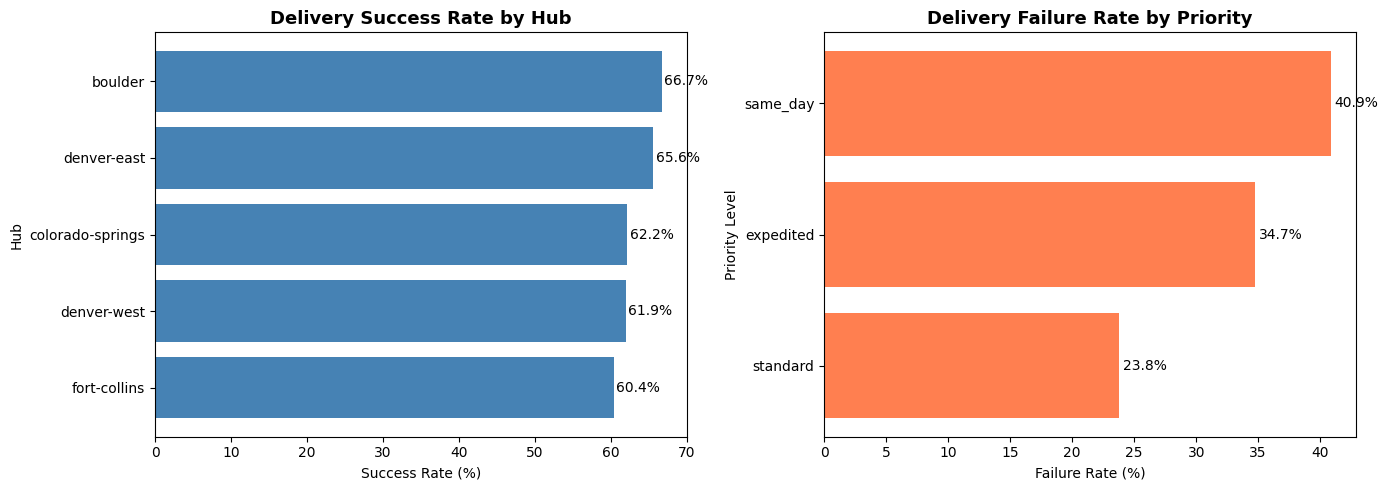

📊 HUB PERFORMANCE ANALYSIS
       hub_clean success_rate_pct
         boulder            66.67
     denver-east            65.57
colorado-springs            62.16
     denver-west            61.93
    fort-collins            60.36
📦 PRIORITY LEVEL RISK ANALYSIS
priority_level_clean failure_rate_pct
            same_day            40.86
           expedited            34.73
            standard            23.80
✅ ACTIONABLE BUSINESS INSIGHTS
Hub Performance Analysis: Best hub is boulder at 66.7% success, worst hub is fort-collins at 60.4%. Performance gap is 6.3 percentage points. Investigate underperforming locations.
Priority Level Risk Analysis: Highest risk is same_day at 40.9% failure, lowest risk is standard at 23.8%. Risk differential is 17.1 percentage points. Align resources with high-risk priorities.
Data Cleaning Impact: Before cleaning: 11 hub name variants and 11 priority variants. After cleaning: 5 standardized hubs and 3 priority levels enable actionable insights.
66.7


In [10]:
# Question 16
import matplotlib.pyplot as plt

# Final cleaned dataset

df_final = df_q15.copy()

# Hub performance analysis
hub_table = (
    df_final.groupby("hub_clean")["delivery_status_clean"]
    .apply(lambda s: (s == "delivered").mean() * 100)
    .sort_values(ascending=False)
    .reset_index(name="success_rate_pct")
)

# Priority level risk analysis
priority_table = (
    df_final.groupby("priority_level_clean")["delivery_status_clean"]
    .apply(lambda s: (s == "failed").mean() * 100)
    .sort_values(ascending=False)
    .reset_index(name="failure_rate_pct")
)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(hub_table["hub_clean"], hub_table["success_rate_pct"], color="steelblue")
axes[0].set_xlabel("Success Rate (%)")
axes[0].set_ylabel("Hub")
axes[0].set_title("Delivery Success Rate by Hub", fontsize=13, fontweight="bold")
axes[0].invert_yaxis()
for i, v in enumerate(hub_table["success_rate_pct"]):
    axes[0].text(v + 0.3, i, f"{v:.1f}%", va="center")

axes[1].barh(priority_table["priority_level_clean"], priority_table["failure_rate_pct"], color="coral")
axes[1].set_xlabel("Failure Rate (%)")
axes[1].set_ylabel("Priority Level")
axes[1].set_title("Delivery Failure Rate by Priority", fontsize=13, fontweight="bold")
axes[1].invert_yaxis()
for i, v in enumerate(priority_table["failure_rate_pct"]):
    axes[1].text(v + 0.3, i, f"{v:.1f}%", va="center")

plt.tight_layout()
plt.show()

# Business insights summary
sep = "=" * 60

print(sep)
print("📊 HUB PERFORMANCE ANALYSIS")
print(sep)
print(hub_table.to_string(index=False, formatters={"success_rate_pct": "{:.2f}".format}))

print(sep)
print("📦 PRIORITY LEVEL RISK ANALYSIS")
print(sep)
print(priority_table.to_string(index=False, formatters={"failure_rate_pct": "{:.2f}".format}))

best_hub = hub_table.iloc[0]
worst_hub = hub_table.iloc[-1]
perf_gap = best_hub["success_rate_pct"] - worst_hub["success_rate_pct"]

highest_risk = priority_table.iloc[0]
lowest_risk = priority_table.iloc[-1]
risk_gap = highest_risk["failure_rate_pct"] - lowest_risk["failure_rate_pct"]

raw_hubs = df_raw["hub"].nunique(dropna=True)
clean_hubs = df_final["hub_clean"].nunique(dropna=True)
raw_priority = df_raw["priority_level"].nunique(dropna=True)
clean_priority = df_final["priority_level_clean"].nunique(dropna=True)

print(sep)
print("✅ ACTIONABLE BUSINESS INSIGHTS")
print(sep)
print(
    "Hub Performance Analysis: "
    f"Best hub is {best_hub['hub_clean']} at {best_hub['success_rate_pct']:.1f}% success, "
    f"worst hub is {worst_hub['hub_clean']} at {worst_hub['success_rate_pct']:.1f}%. "
    f"Performance gap is {perf_gap:.1f} percentage points. Investigate underperforming locations."
)
print(
    "Priority Level Risk Analysis: "
    f"Highest risk is {highest_risk['priority_level_clean']} at {highest_risk['failure_rate_pct']:.1f}% failure, "
    f"lowest risk is {lowest_risk['priority_level_clean']} at {lowest_risk['failure_rate_pct']:.1f}%. "
    f"Risk differential is {risk_gap:.1f} percentage points. Align resources with high-risk priorities."
)
print(
    "Data Cleaning Impact: "
    f"Before cleaning: {raw_hubs} hub name variants and {raw_priority} priority variants. "
    f"After cleaning: {clean_hubs} standardized hubs and {clean_priority} priority levels enable actionable insights."
)

# What is the delivery success rate (percentage of 'delivered' status) for the hub with the highest success rate, rounded to 1 decimal place?
success_rate = round(best_hub['success_rate_pct'], 1)
print(success_rate)

### Save Cleaned Dataset

Export the fully cleaned and processed dataset to CSV for use in downstream analysis and modeling.


In [12]:
# Save the cleaned dataset
output_path = "last_mile_delivery_stops_1000_CLEANED.csv"
df_final.to_csv(output_path, index=False)

print(f"✅ Cleaned dataset saved to: {output_path}")
print(f"📊 Shape: {df_final.shape[0]} rows × {df_final.shape[1]} columns")
print(f"📋 Columns: {', '.join(df_final.columns.tolist())}")


✅ Cleaned dataset saved to: last_mile_delivery_stops_1000_CLEANED.csv
📊 Shape: 1000 rows × 80 columns
📋 Columns: stop_id, route_id, driver_id, vehicle_id, hub, delivery_zone, delivery_note, customer_type, priority_level, signature_required, weather, stop_datetime_raw, scheduled_window_start_raw, scheduled_window_min, actual_delivery_time_raw, actual_arrival_min, packages_count, package_weight_lb_raw, package_weight_lb, distance_from_prev_mi, service_time_min, fuel_cost_usd, tip_usd, customer_claim_usd, cargo_temp_f, gps_accuracy_m, device_battery_pct, delivery_status, failure_reason, customer_satisfaction, internal_comment, hub_clean, delivery_zone_clean, customer_type_clean, priority_level_clean, delivery_status_clean, stop_datetime, scheduled_window_start, stop_dayofweek, stop_is_weekend, lateness_min, stop_id_binned, route_id_binned, driver_id_binned, vehicle_id_binned, hub_binned, delivery_zone_binned, delivery_note_binned, customer_type_binned, priority_level_binned, weather_binne